In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario")
csv_files = sorted(results_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir}")

required_cols = {"scenario", "total_params", "val_l2", "val_mse"}
csv_files

[PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario/coupling_scenario_01_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario/coupling_scenario_02_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario/coupling_scenario_03_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario/coupling_scenario_04_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenario/coupling_scenario_05_fno_sweep_results.csv')]

In [2]:
records = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing required columns: {sorted(missing)}")
    records.append(df.sort_values("total_params"))

plot_df = pd.concat(records, ignore_index=True)
plot_df.head()

,timestamp,scenario,hidden_channels,n_modes_x,n_modes_y,n_layers,total_params,train_l2,val_l2,train_mse,val_mse,epochs,batch_size,learning_rate,weight_decay,normalize,scheduler_enabled,scheduler_step_size,scheduler_decay,device
0,2026-04-10T07:38:40,scenario_01,8,8,16,4,44330,0.411800,0.340789,9.968935,9.710614,120,512,0.001,0.0,True,True,5,0.98,cuda
1,2026-04-10T07:44:26,scenario_01,16,8,16,4,159826,0.388469,0.314340,4.858484,4.695761,120,512,0.001,0.0,True,True,5,0.98,cuda
2,2026-04-10T07:51:25,scenario_01,32,8,16,4,613538,0.413867,0.340958,11.330786,11.038187,120,512,0.001,0.0,True,True,5,0.98,cuda
3,2026-04-10T08:00:53,scenario_01,64,8,16,4,2411842,0.395016,0.319358,6.278835,6.081376,120,512,0.001,0.0,True,True,5,0.98,cuda
4,2026-04-10T08:16:16,scenario_01,128,8,16,4,9571970,0.426262,0.350729,4.891123,4.769009,120,512,0.001,0.0,True,True,5,0.98,cuda


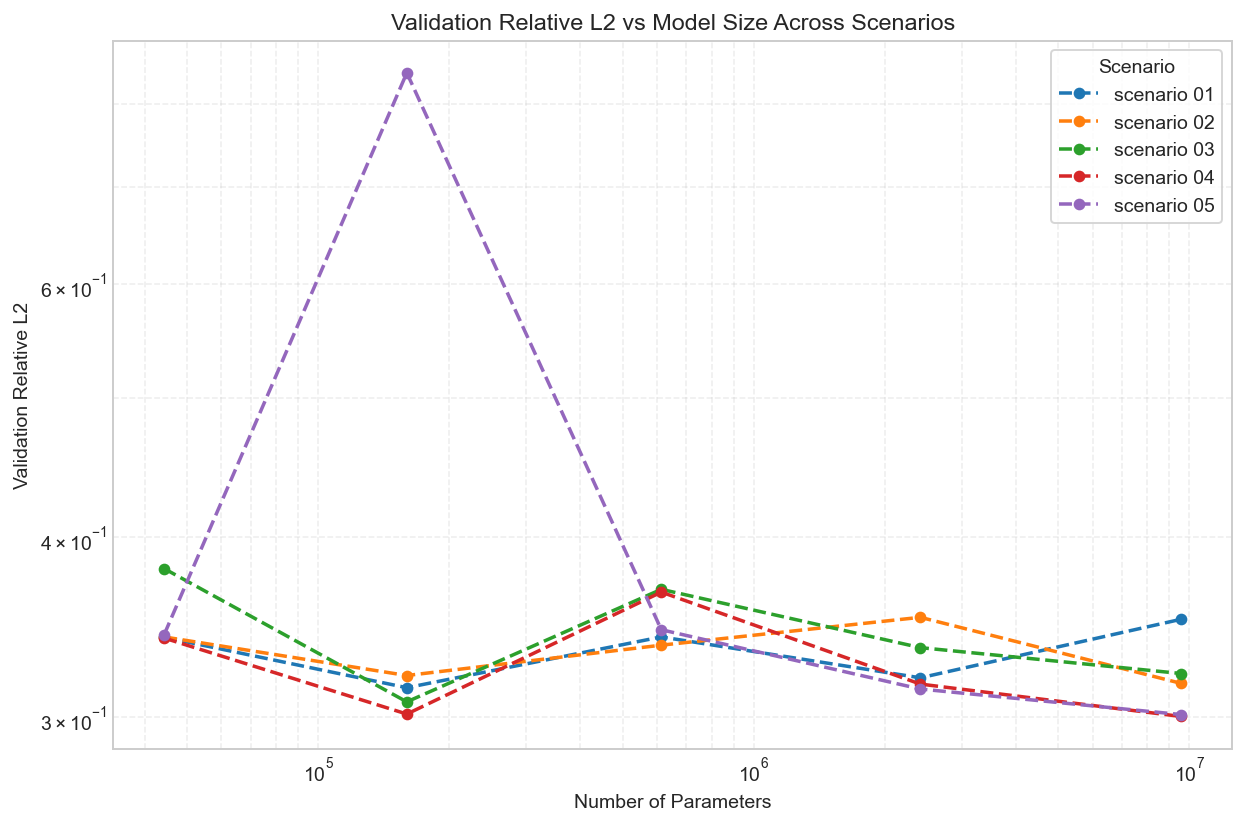

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(9, 6), dpi=140)
scenarios = sorted(plot_df["scenario"].unique())

for scenario in scenarios:
    sub = plot_df[plot_df["scenario"] == scenario].sort_values("total_params")
    ax.plot(
        sub["total_params"],
        sub["val_l2"],
        marker="o" ,
        linestyle="--",
        linewidth=1.8,
        markersize=5,
        label=scenario.replace("_", " ")
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Validation Relative L2")
ax.set_title("Validation Relative L2 vs Model Size Across Scenarios")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(title="Scenario", frameon=True)
plt.tight_layout()
plt.show()

In [4]:
summary = (
    plot_df.sort_values(["scenario", "val_l2"])
    .groupby("scenario", as_index=False)
    .first()[["scenario", "hidden_channels", "total_params", "val_l2", "val_mse"]]
    .rename(
        columns={
            "hidden_channels": "best_hidden_channels",
            "total_params": "best_total_params",
            "val_l2": "best_val_l2",
            "val_mse": "best_val_mse"
        }
    )
    .sort_values("scenario")
)

summary

,scenario,best_hidden_channels,best_total_params,best_val_l2,best_val_mse
0,scenario_01,16,159826,0.314340,4.695761
1,scenario_02,128,9571970,0.316525,1.628234
2,scenario_03,16,159826,0.307298,0.480009
3,scenario_04,128,9571970,0.300188,0.431028
4,scenario_05,128,9571970,0.301116,0.351043
